<a href="https://www.kaggle.com/code/lalit7881/real-estate-intelligence-eda?scriptVersionId=310654479" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jahnavikachhia23/texas-residential-real-estate-intelligence-2026/Texas_Residential_Real Estate_Intelligenc_ 2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/jahnavikachhia23/texas-residential-real-estate-intelligence-2026/Texas_Residential_Real Estate_Intelligenc_ 2026.csv")

In [3]:
df.head()

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
0,single_family,NaN,Experience The Best Of North Texas Living In T...,499000.0,2040.0,2.0,3.0,3.0,2.0,2.0,2.0,2021.0,244.61
1,single_family,NaN,"Welcome home to [Redacted Entity], [Redacted E...",494500.0,3674.0,2.0,6.0,4.0,3.0,3.0,NaN,2025.0,134.59
2,single_family,NaN,Welcome to this beautiful home located in [Red...,229000.0,1650.0,2.0,3.0,3.0,2.0,2.0,2.0,2020.0,138.79
3,single_family,NaN,"Welcome to [Redacted Entity] - where style, co...",260000.0,1741.0,1.0,3.0,2.0,2.0,2.0,2.0,2005.0,149.34
4,single_family,single family detached,***READY NOW*** Discover this stunning new con...,334990.0,2255.0,2.0,4.0,4.0,3.0,3.0,2.0,2025.0,148.55


In [4]:
df.tail()

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
12132,condos,condo,Welcome to [Redacted Entity] in the Heart of [...,222000.0,1495.0,2.0,2.0,3.0,2.0,2.0,NaN,1968.0,148.49
12133,single_family,NaN,Welcome home to this charming farmhouse-style ...,459900.0,2414.0,2.0,4.0,3.0,2.0,2.0,2.0,2021.0,190.51
12134,single_family,NaN,"Welcome to [Redacted Entity], a beautifully ma...",405000.0,3428.0,2.0,4.0,4.0,3.0,3.0,2.0,1984.0,118.14
12135,single_family,NaN,BEACHSIDE GEM HAS IT ALL! Lovely 3/2 in the he...,399000.0,1260.0,1.0,3.0,2.0,2.0,2.0,1.0,2008.0,316.67
12136,single_family,NaN,This beautifully maintained home sits on 1.83 ...,545000.0,2724.0,2.0,4.0,3.0,2.0,2.0,3.0,2007.0,200.07


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12137 entries, 0 to 12136
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   type             12137 non-null  object 
 1   sub_type         1749 non-null   object 
 2   text             12137 non-null  object 
 3   listPrice        12134 non-null  float64
 4   sqft             12073 non-null  float64
 5   stories          11630 non-null  float64
 6   beds             12009 non-null  float64
 7   baths            11863 non-null  float64
 8   baths_full       11988 non-null  float64
 9   baths_full_calc  11991 non-null  float64
 10  garage           10224 non-null  float64
 11  year_built       9849 non-null   float64
 12  Price_Per_SqFt   12135 non-null  float64
dtypes: float64(10), object(3)
memory usage: 1.2+ MB


In [6]:
df.describe()

,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built,Price_Per_SqFt
count,1.213400e+04,12073.000000,11630.000000,12009.000000,11863.000000,11988.000000,11991.000000,10224.000000,9849.000000,12135.000000
mean,4.998792e+05,2286.140230,1.442562,3.611791,2.882660,2.475142,2.480527,2.134390,2013.043050,208.948589
std,5.409439e+05,1048.659141,0.549794,1.014476,1.191023,0.917721,0.915769,0.605927,22.132438,139.697072
min,8.500000e+02,240.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1654.000000,0.000000
25%,2.880922e+05,1640.000000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2015.000000,154.915000
50%,3.749000e+05,2085.000000,1.000000,4.000000,3.000000,2.000000,2.000000,2.000000,2023.000000,182.910000
75%,5.390000e+05,2686.000000,2.000000,4.000000,3.000000,3.000000,3.000000,2.000000,2025.000000,220.840000
max,1.199500e+07,19600.000000,7.000000,29.000000,39.000000,26.000000,26.000000,20.000000,2028.000000,6363.980000


In [7]:
df.isnull().sum()

type                   0
sub_type           10388
text                   0
listPrice              3
sqft                  64
stories              507
beds                 128
baths                274
baths_full           149
baths_full_calc      146
garage              1913
year_built          2288
Price_Per_SqFt         2
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(63)

In [9]:
df.columns

Index(['type', 'sub_type', 'text', 'listPrice', 'sqft', 'stories', 'beds',
       'baths', 'baths_full', 'baths_full_calc', 'garage', 'year_built',
       'Price_Per_SqFt'],
      dtype='object')

In [10]:
df.dtypes

type                object
sub_type            object
text                object
listPrice          float64
sqft               float64
stories            float64
beds               float64
baths              float64
baths_full         float64
baths_full_calc    float64
garage             float64
year_built         float64
Price_Per_SqFt     float64
dtype: object

In [11]:
df.shape

(12137, 13)

In [12]:
df.nunique()

type                   6
sub_type              11
text               11512
listPrice           4228
sqft                3247
stories                6
beds                  18
baths                 18
baths_full            16
baths_full_calc       16
garage                12
year_built           124
Price_Per_SqFt      8753
dtype: int64

## EDA

            type                sub_type  \
0  single_family                     NaN   
1  single_family                     NaN   
2  single_family                     NaN   
3  single_family                     NaN   
4  single_family  single family detached   

                                                text  listPrice    sqft  \
0  Experience The Best Of North Texas Living In T...   499000.0  2040.0   
1  Welcome home to [Redacted Entity], [Redacted E...   494500.0  3674.0   
2  Welcome to this beautiful home located in [Red...   229000.0  1650.0   
3  Welcome to [Redacted Entity] - where style, co...   260000.0  1741.0   
4  ***READY NOW*** Discover this stunning new con...   334990.0  2255.0   

   stories  beds  baths  baths_full  baths_full_calc  garage  year_built  \
0      2.0   3.0    3.0         2.0              2.0     2.0      2021.0   
1      2.0   6.0    4.0         3.0              3.0     NaN      2025.0   
2      2.0   3.0    3.0         2.0              2.0    

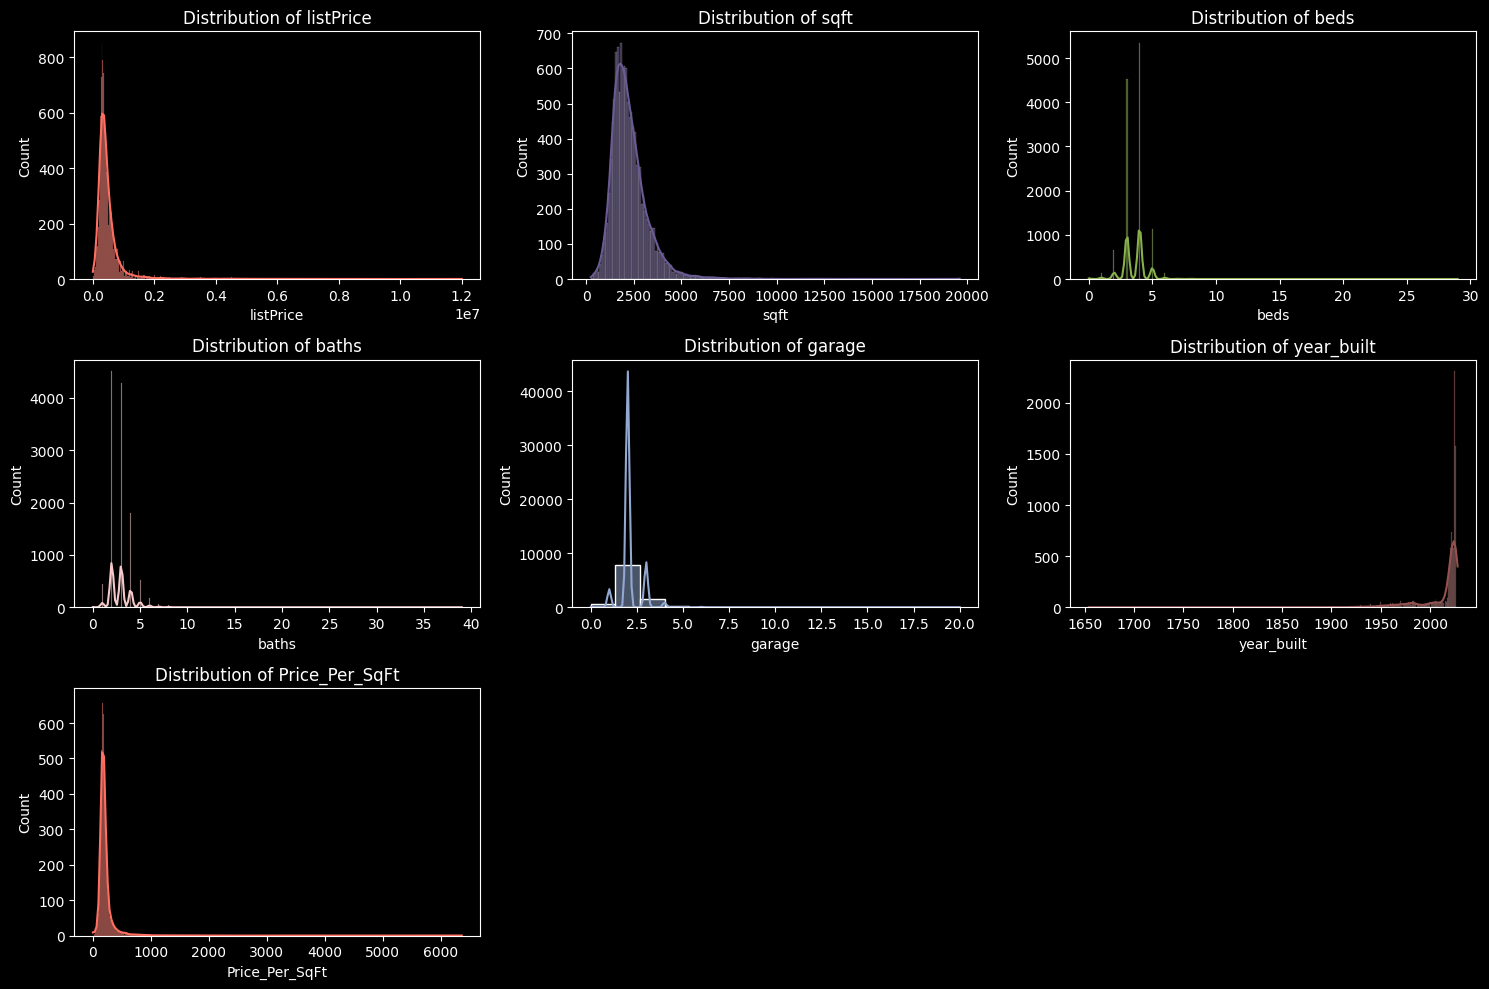

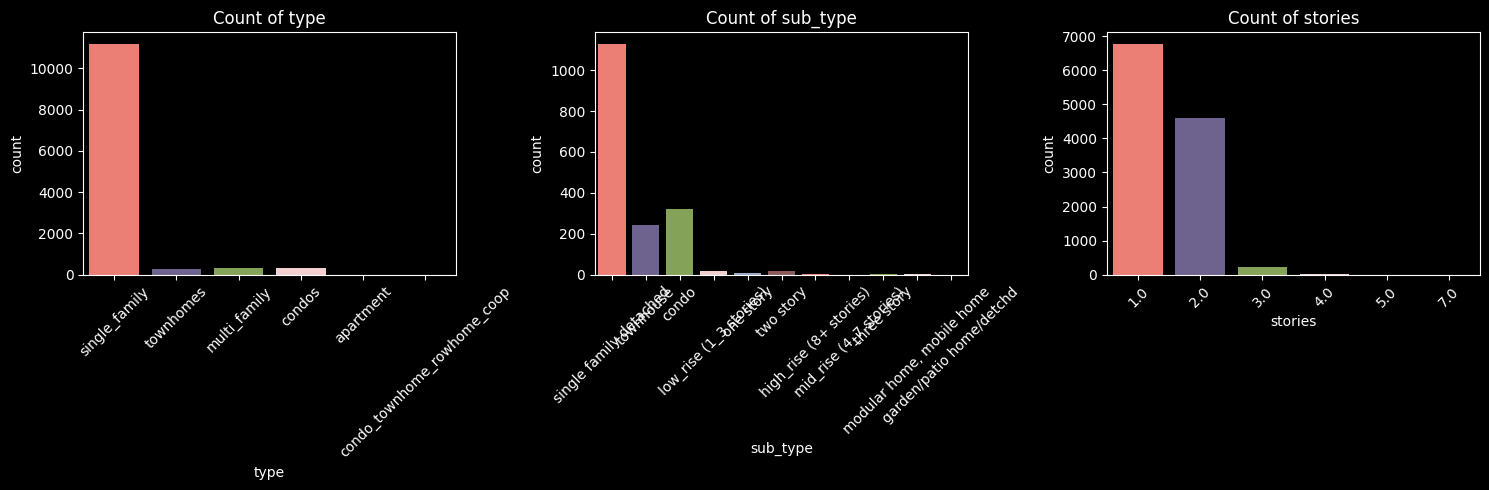

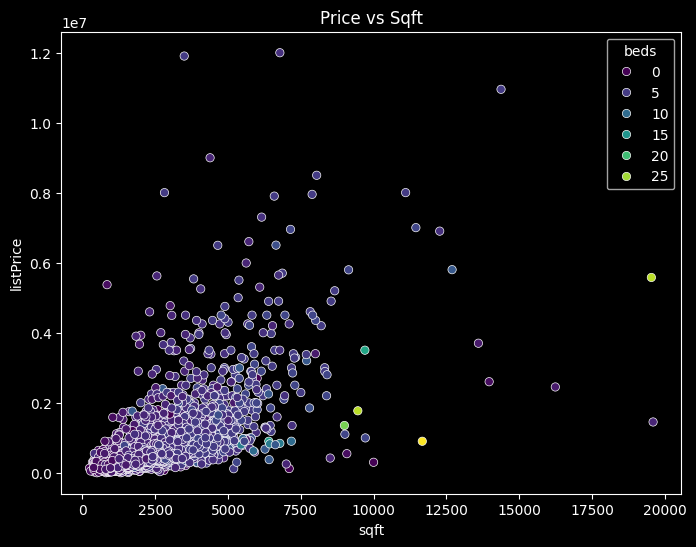

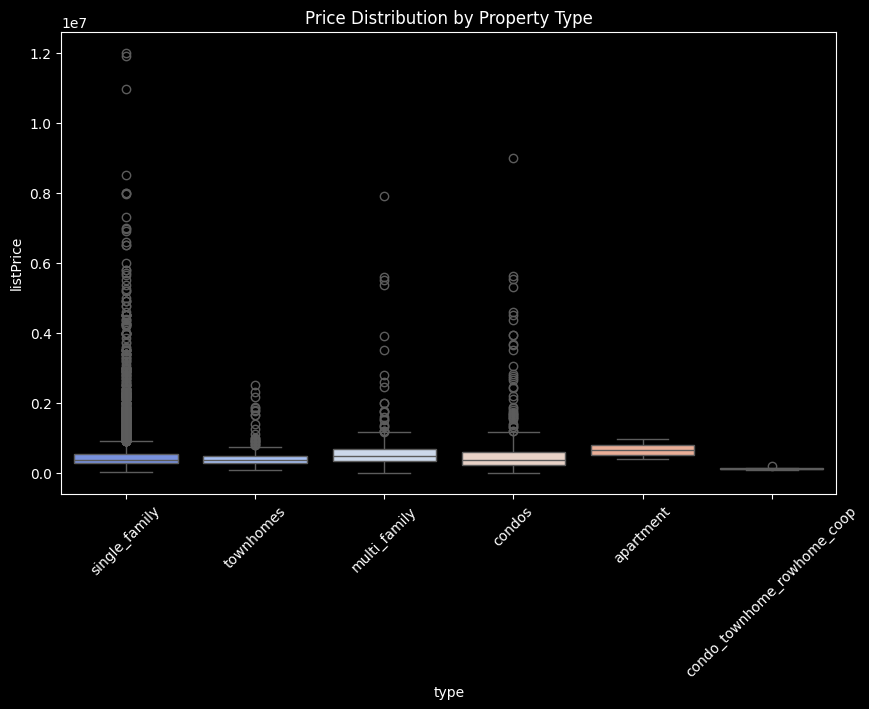

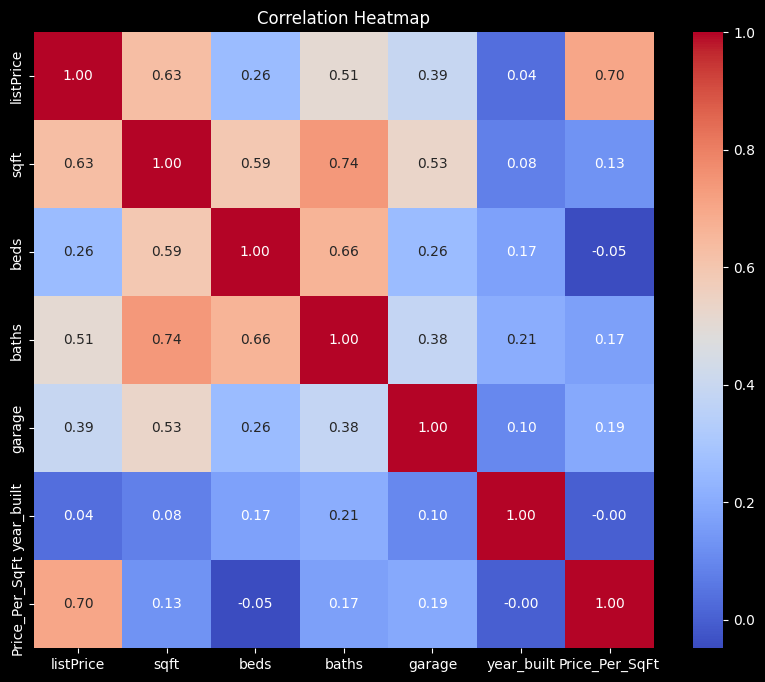

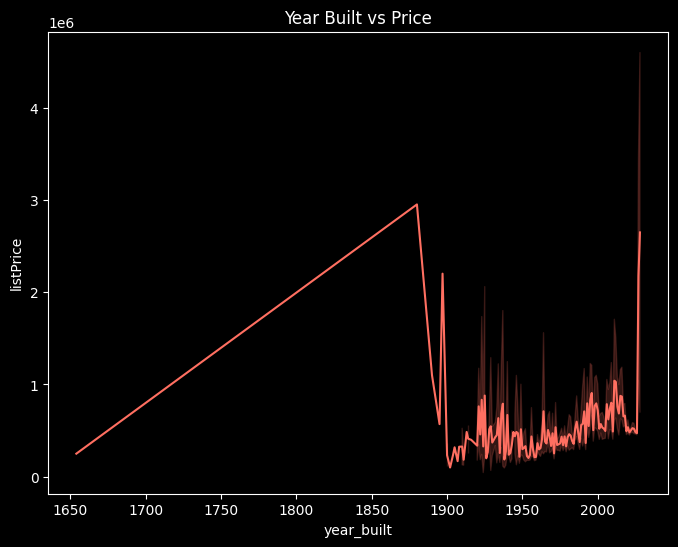

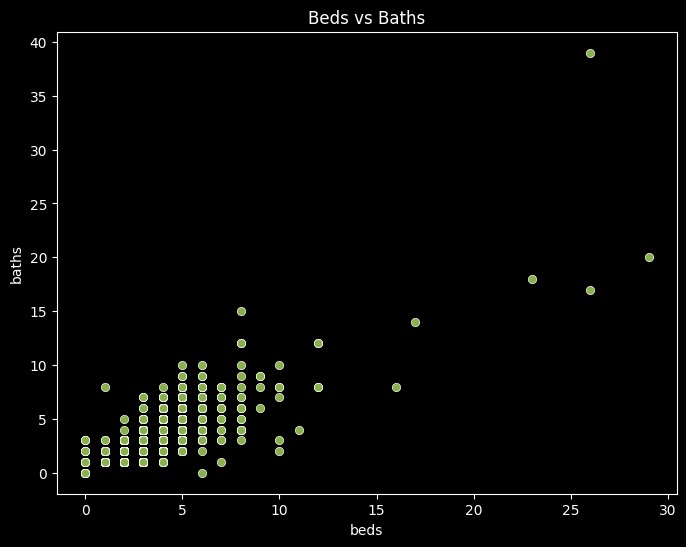

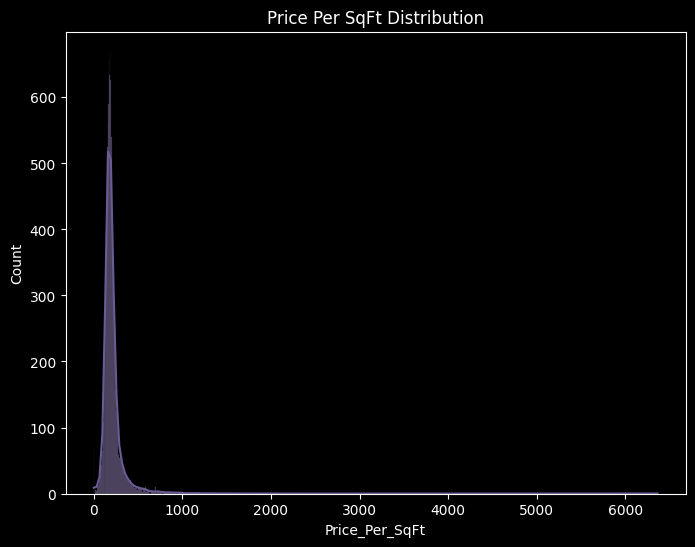

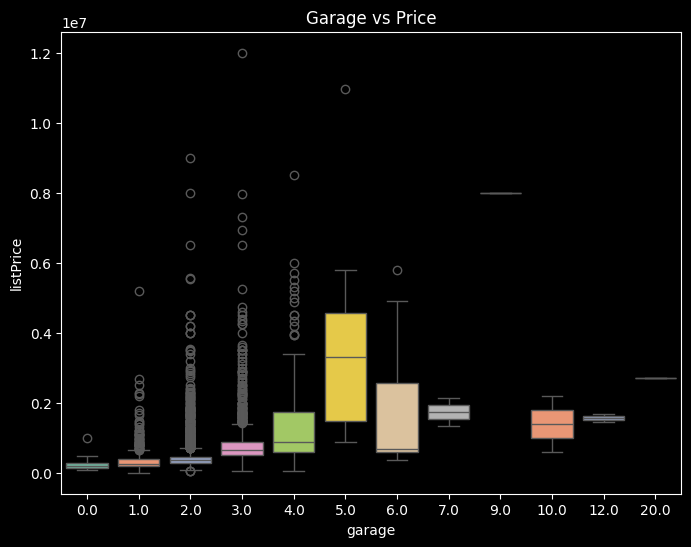

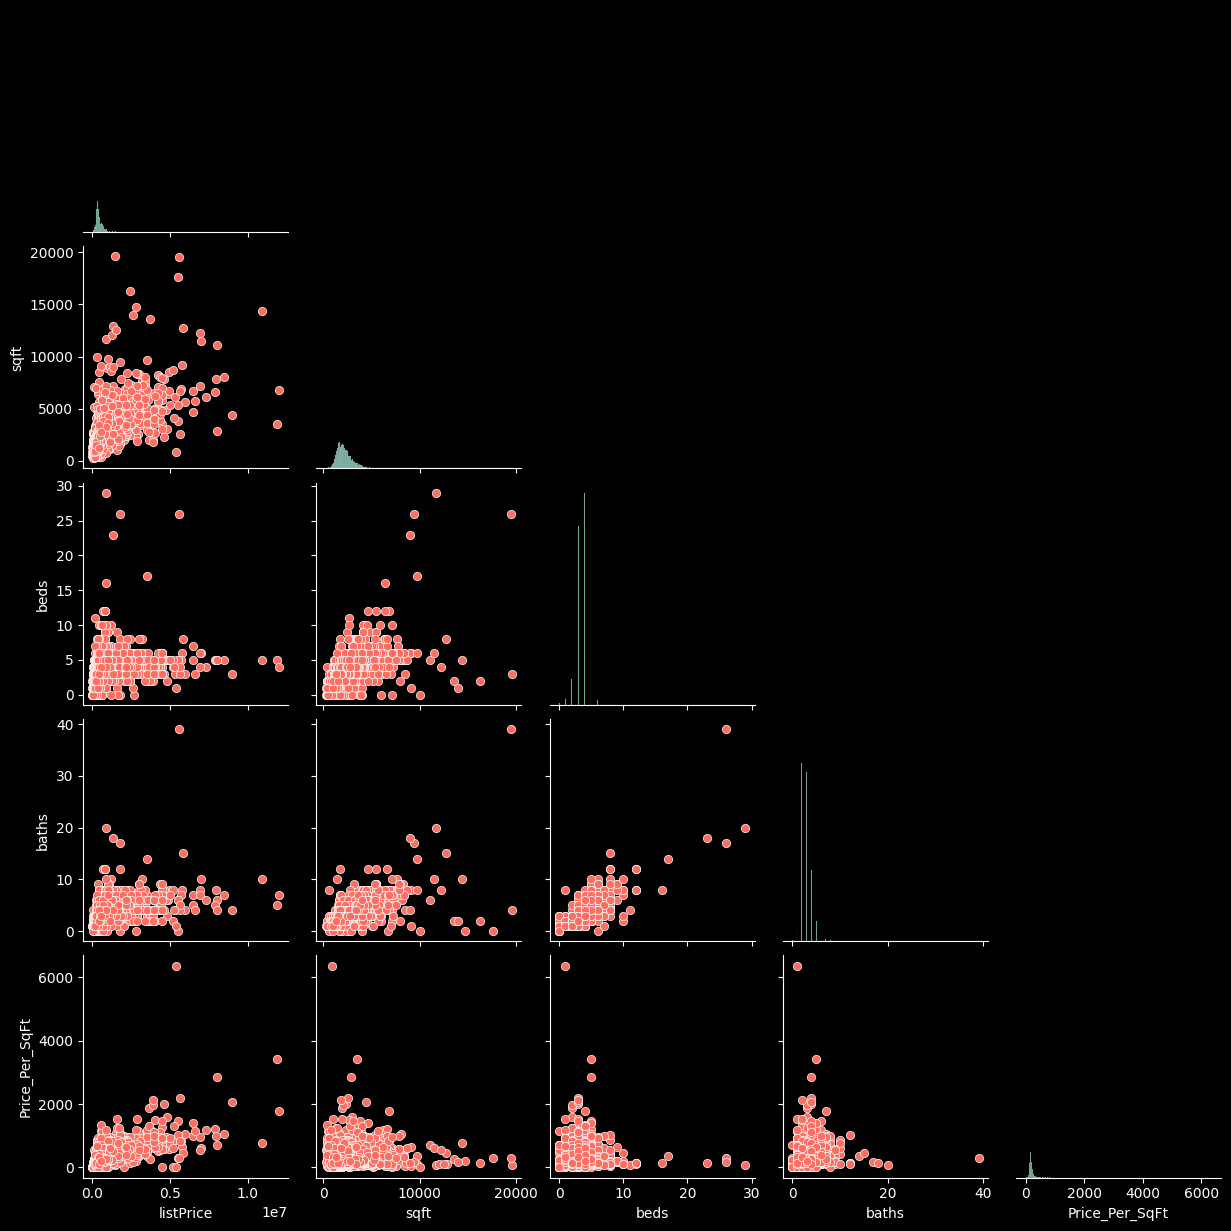

In [13]:

plt.style.use('dark_background')

# Custom color palette
colors = ['#FF6F61', '#6B5B95', '#88B04B', '#F7CAC9', '#92A8D1', '#955251']

# ===========================
# BASIC INFO
# ===========================
print(df.head())
print(df.info())

# ===========================
# 1. DISTRIBUTION PLOTS
# ===========================
num_cols = ['listPrice', 'sqft', 'beds', 'baths', 'garage', 'year_built', 'Price_Per_SqFt']

plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
    plt.subplot(3,3,i+1)
    sns.histplot(df[col], kde=True, color=colors[i % len(colors)])
    plt.title(f'Distribution of {col}', color='white')
plt.tight_layout()
plt.show()

# ===========================
# 2. COUNT PLOTS (CATEGORICAL)
# ===========================
cat_cols = ['type', 'sub_type', 'stories']

plt.figure(figsize=(15,5))
for i, col in enumerate(cat_cols):
    plt.subplot(1,3,i+1)
    sns.countplot(data=df, x=col, palette=colors)
    plt.xticks(rotation=45)
    plt.title(f'Count of {col}', color='white')
plt.tight_layout()
plt.show()

# ===========================
# 3. PRICE VS SQFT
# ===========================
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='sqft', y='listPrice', hue='beds', palette='viridis')
plt.title('Price vs Sqft', color='white')
plt.show()

# ===========================
# 4. BOX PLOT (PRICE BY TYPE)
# ===========================
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='type', y='listPrice', palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Price Distribution by Property Type', color='white')
plt.show()

# ===========================
# 5. CORRELATION HEATMAP
# ===========================
plt.figure(figsize=(10,8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap', color='white')
plt.show()

# ===========================
# 6. YEAR BUILT VS PRICE
# ===========================
plt.figure(figsize=(8,6))
sns.lineplot(data=df, x='year_built', y='listPrice', color='#FF6F61')
plt.title('Year Built vs Price', color='white')
plt.show()

# ===========================
# 7. BEDS & BATHS RELATION
# ===========================
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='beds', y='baths', color='#88B04B')
plt.title('Beds vs Baths', color='white')
plt.show()

# ===========================
# 8. PRICE PER SQFT DISTRIBUTION
# ===========================
plt.figure(figsize=(8,6))
sns.histplot(df['Price_Per_SqFt'], kde=True, color='#6B5B95')
plt.title('Price Per SqFt Distribution', color='white')
plt.show()

# ===========================
# 9. GARAGE VS PRICE
# ===========================
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='garage', y='listPrice', palette='Set2')
plt.title('Garage vs Price', color='white')
plt.show()

# ===========================
# 10. PAIRPLOT (IMPORTANT FEATURES)
# ===========================
sns.pairplot(df[['listPrice', 'sqft', 'beds', 'baths', 'Price_Per_SqFt']], 
             corner=True, plot_kws={'color': '#FF6F61'})
plt.show()

## Feature engineering


Logistic Regression Accuracy: 0.9209
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         2
           2       0.36      0.07      0.12        68
           3       0.67      0.03      0.06        60
           4       0.92      1.00      0.96      2238
           5       0.00      0.00      0.00        59

    accuracy                           0.92      2428
   macro avg       0.32      0.18      0.19      2428
weighted avg       0.88      0.92      0.89      2428


Decision Tree Accuracy: 0.9778
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         2
           2       0.96      1.00      0.98        68
           3       0.82      0.47      0.60        60
           4       0.98      1.00      0.99      2238
           5       0.98      0.80      0.88        59

    acc

<Figure size 1000x800 with 0 Axes>

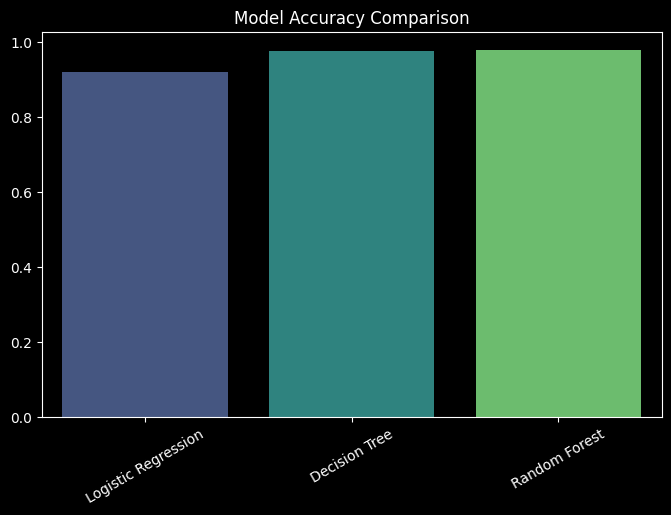


Best Model: Random Forest with accuracy 0.9794


In [14]:
# ===========================
# IMPORT LIBRARIES
# ===========================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier



# ===========================
# TARGET & FEATURES
# ===========================
target = 'type'

X = df.drop(columns=[target])
y = df[target]

# ===========================
# TRAIN TEST SPLIT
# ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===========================
# ENCODE TARGET
# ===========================
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

# ===========================
# COLUMN TYPES
# ===========================
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

# ===========================
# PIPELINES (IMPUTATION + ENCODING)
# ===========================

# Categorical pipeline
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Numerical pipeline
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipeline, cat_cols),
        ('num', num_pipeline, num_cols)
    ]
)

# ===========================
# MODELS
# ===========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

# ===========================
# TRAIN + EVALUATE
# ===========================
results = {}

plt.style.use('dark_background')
plt.figure(figsize=(10,8))

for name, model in models.items():
    
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipe.fit(X_train, y_train)
    
    # Predict
    y_pred = pipe.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    
    # ROC (only if binary)
    if len(np.unique(y_test)) == 2:
        y_prob = pipe.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# ===========================
# ROC CURVE
# ===========================
if len(np.unique(y_test)) == 2:
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate", color='white')
    plt.ylabel("True Positive Rate", color='white')
    plt.title("ROC Curve", color='white')
    plt.legend()
    plt.show()

# ===========================
# ACCURACY COMPARISON
# ===========================
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title("Model Accuracy Comparison", color='white')
plt.xticks(rotation=30)
plt.show()

# ===========================
# BEST MODEL
# ===========================
best_model = max(results, key=results.get)
print(f"\nBest Model: {best_model} with accuracy {results[best_model]:.4f}")

## Thank you..pls upvote!!!!!!!